###  **Note sul progetto** ###

Avvertenza sul training del modello EfficientNet:
In riferimento ai feedback ricevuti, ho integrato nel notebook anche la costruzione del modello EfficientNet e la relativa pipeline di addestramento.


###***Introduzione al progetto***



In questo progetto, ho deciso di affrontare il task di food classification tramite tecniche di deep learning e transfer learning. Dopo aver scaricato e preparato un dataset dedicato alla classificazione di diverse categorie di cibo, ho ritenuto opportuno effettuare operazioni di preprocessing, normalizzazione e data augmentation al fine di massimizzare la generalizzazione e la robustezza dei modelli.

Sono stati implementati e confrontati due differenti approcci di rete neurale convolutionale:

VGG16, storicamente molto usato e ben consolidato per compiti di classificazione;
EfficientNetV2, uno dei modelli più recenti e performanti, per mostrare eventuali miglioramenti rispetto a soluzioni più tradizionali.

Ho inoltre illustrato gli steps fondamentali del workflow di deep learning: caricamento e analisi dati, data augmentation, definizione dei modelli, training e valutazione tramite precision, recall, f1-score e visualizzazione della confusion matrix.

### ***Download ed estrazione dataset***

In [ ]:
import os
import random
import json
import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.models import vgg16, VGG16_Weights, efficientnet_v2_s, EfficientNet_V2_S_Weights
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.transforms.functional import to_pil_image
import urllib.request
import zipfile
from PIL import Image



# Scarico il dataset
url = "https://proai-datasets.s3.eu-west-3.amazonaws.com/dataset_food_classification.zip"
dataset_path = "dataset_food_classification.zip"
dataset_dir = "/content/dataset"

if not os.path.exists(dataset_dir):
    os.makedirs(dataset_dir)

# Scarico il file zip
if not os.path.exists(dataset_path):
    print("Scaricando il dataset...")
    urllib.request.urlretrieve(url, dataset_path)
    print("Download completato.")

# Estraggo il dataset
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)
    print("Estrazione completata.")

# Verifico il contenuto della directory subito dopo l'estrazione
extracted_dir = os.path.join(dataset_dir, "dataset")  # Aggiorno il percorso
print("Contenuto della directory estratta:")
for item in os.listdir(extracted_dir):
    print(item)

# Verifica che le cartelle siano state create
train_dir = os.path.join(extracted_dir, "train")  # Aggiorno il percorso
val_dir = os.path.join(extracted_dir, "val")      # Aggiorno il percorso
test_dir = os.path.join(extracted_dir, "test")    # Aggiorno il percorso

# Controlla l'esistenza delle cartelle
assert os.path.exists(train_dir), f"La cartella {train_dir} non esiste."
assert os.path.exists(val_dir), f"La cartella {val_dir} non esiste."
assert os.path.exists(test_dir), f"La cartella {test_dir} non esiste."

print("Tutte le cartelle sono state create correttamente.")

Scaricando il dataset...
Download completato.
Estrazione completata.
Contenuto della directory estratta:
train
test
val
Tutte le cartelle sono state create correttamente.


### ***Impostazione dei seed per la riproducibilità***

In [ ]:
# Imposto il seed per la riproducibilità
seed = 42
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


### ***Trasformazioni e augmentation***

In [ ]:
class Transforms:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']

transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

augment = A.Compose([
    A.Resize(256, 256),
    A.RandomRotate90(),
    A.HorizontalFlip(),
    A.Transpose(),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


#Su suggerimento del docente ho corretto la normalizzazione con valore 0,5 portandola ai valori mean=[0.485,0.456,0.406] e std=[0.229,0.224,0.225] che sono quelli utilizzati per addestramento delle reti pre-allenate di torchvision (come VGG ed EfficientNet)
#Ho inoltre riportato lo step di normalizzazione per "augment" prima di ToTensorV2()

### ***Caricamento del dataset***

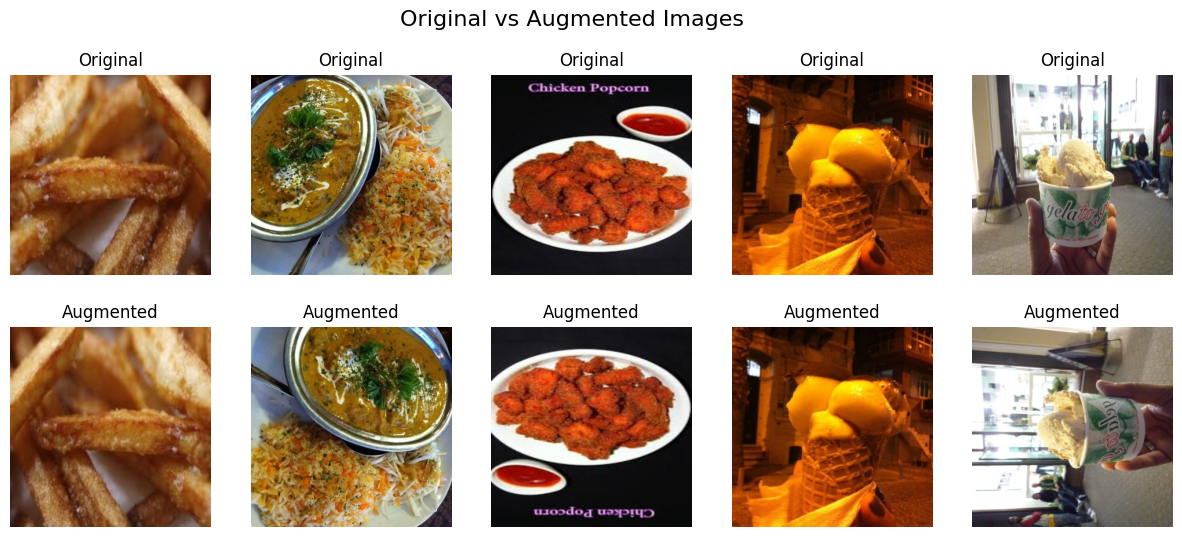

In [ ]:
# Creo i dataset utilizzando ImageFolder
trainset = torchvision.datasets.ImageFolder(root=train_dir, transform=Transforms(augment))
valset = torchvision.datasets.ImageFolder(root=val_dir, transform=Transforms(transform))
testset = torchvision.datasets.ImageFolder(root=test_dir, transform=Transforms(transform))

# Visualizzazione delle immagini
'''def show_images(dataset, num_images=5):
    fig, axs = plt.subplots(2, num_images, figsize=(15, 6))
    fig.suptitle('Original vs Augmented Images', fontsize=16)

    for i in range(num_images):
        img, _ = dataset[i]
        axs[0, i].imshow(to_pil_image(img))
        axs[0, i].axis('off')

        aug_img = augment(image=np.array(to_pil_image(img)))['image']
        axs[1, i].imshow(to_pil_image(aug_img))
        axs[1, i].axis('off')

    plt.show()

show_images(trainset)'''

# Definisco una transform solo per augmentation (senza la parte Normalize)
show_augment = A.Compose([
    A.Resize(256, 256),
    A.RandomRotate90(),
    A.HorizontalFlip(),
    A.Transpose(),
])

def denorm(img_tensor, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
    img = img_tensor.clone().detach().cpu()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)
    return img

# Creo una nuova funzione di show
def show_images_original_augment(dataset, num_images=5):
    fig, axs = plt.subplots(2, num_images, figsize=(15, 6))
    fig.suptitle('Original vs Augmented Images', fontsize=16)

    indices = np.random.choice(len(dataset), num_images, replace=False)
    for i, idx in enumerate(indices):
        img_path, _ = dataset.samples[idx]
        img = Image.open(img_path).convert('RGB')
        axs[0, i].imshow(img)
        axs[0, i].axis('off')
        axs[0, i].set_title('Original')

        # L’augmenter lavora su numpy, la conversione colore è già fatta
        aug_img = show_augment(image=np.array(img))['image']
        axs[1, i].imshow(aug_img)
        axs[1, i].axis('off')
        axs[1, i].set_title('Augmented')

    plt.show()

show_images_original_augment(trainset)

# Definisco le dimensioni del batch
batch_size = 128

# Creo i dataloader
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False)


#In questa sezione del codice, su suggerimento del docente, ho corretto il codice per mostrare le immagini senza vedere effetto della normalizzazione. Ho lasciato il vecchio codice relativo allo show images tra apici per tenere traccia.

### ***Definizione della rete neurale con Transfer Learning***

In [ ]:
# Freeze layers
vgg_backbone = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).to(device)
for param in vgg_backbone.parameters():
    param.requires_grad = False

class VGGClassifier(nn.Module):
    def __init__(self, vgg_backbone, in_features, num_classes):
        super().__init__()
        self.features = vgg_backbone.features
        self.pooling = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(in_features, num_classes)
    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

vgg = VGGClassifier(vgg_backbone, 512, len(trainset.classes)).to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 201MB/s]


### ***Definizione della rete neurale EfficientNet con Transfer Learning***

In [ ]:
efficientnet_backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1).to(device)
for param in efficientnet_backbone.parameters():
    param.requires_grad = False

class EfficientNetClassifier(nn.Module):
    def __init__(self, efficientnet_backbone, num_classes):
        super().__init__()
        self.features = efficientnet_backbone.features
        self.pooling = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(efficientnet_backbone.classifier[1].in_features, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pooling(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

efficientnet = EfficientNetClassifier(efficientnet_backbone, len(trainset.classes)).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 219MB/s]


#### ***Funzioni di training e di testing***

In [ ]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):
        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_loss, model):
        if self.min_val_loss is None:
            self.min_val_loss = validation_loss
            self.save_checkpoint(model)
        elif (self.min_val_loss - validation_loss) > self.min_delta:
            self.min_val_loss = validation_loss
            self.save_checkpoint(model)
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.save_path)

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for data in train_loader:
        inputs, labels = data[0].to(device), data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(train_loader)

def test_epoch(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / len(test_loader), correct / total

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=100, early_stopping=None):
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy = test_epoch(model, val_loader, criterion, device)
        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}')
        if early_stopping is not None:
            early_stopping(val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping")
                break


### ***Training del modello VGG***

In [ ]:
vgg_save_folder = "models/vgg/"
os.makedirs(vgg_save_folder, exist_ok=True)
vgg_save_file = os.path.join(vgg_save_folder, "model.pt")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg.parameters(), lr=0.001)
early_stopping = EarlyStopping(vgg_save_file, patience=5, min_delta=0)

train_model(vgg, trainloader, valloader, criterion, optimizer, device, epochs=100, early_stopping=early_stopping)

Epoch 1/100, Train Loss: 2.0257, Val Loss: 1.5310, Val Accuracy: 0.6692
Epoch 2/100, Train Loss: 1.3642, Val Loss: 1.1679, Val Accuracy: 0.7237
Epoch 3/100, Train Loss: 1.1237, Val Loss: 1.0062, Val Accuracy: 0.7420
Epoch 4/100, Train Loss: 0.9955, Val Loss: 0.9161, Val Accuracy: 0.7558
Epoch 5/100, Train Loss: 0.9079, Val Loss: 0.8559, Val Accuracy: 0.7696
Epoch 6/100, Train Loss: 0.8507, Val Loss: 0.8102, Val Accuracy: 0.7732
Epoch 7/100, Train Loss: 0.8116, Val Loss: 0.7782, Val Accuracy: 0.7768
Epoch 8/100, Train Loss: 0.7793, Val Loss: 0.7482, Val Accuracy: 0.7804
Epoch 9/100, Train Loss: 0.7487, Val Loss: 0.7275, Val Accuracy: 0.7853
Epoch 10/100, Train Loss: 0.7121, Val Loss: 0.7091, Val Accuracy: 0.7888
Epoch 11/100, Train Loss: 0.7070, Val Loss: 0.6938, Val Accuracy: 0.7906
Epoch 12/100, Train Loss: 0.6814, Val Loss: 0.6777, Val Accuracy: 0.7978
Epoch 13/100, Train Loss: 0.6658, Val Loss: 0.6678, Val Accuracy: 0.7933
Epoch 14/100, Train Loss: 0.6611, Val Loss: 0.6577, Val Accu

### ***Training del modello EfficientNet***

In [ ]:
efficientnet_save_folder = "models/efficientnet/"
os.makedirs(efficientnet_save_folder, exist_ok=True)
efficientnet_save_file = os.path.join(efficientnet_save_folder, "model.pt")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(efficientnet.parameters(), lr=0.001)
early_stopping = EarlyStopping(efficientnet_save_file, patience=5, min_delta=0)

train_model(efficientnet, trainloader, valloader, criterion, optimizer, device, epochs=100, early_stopping=early_stopping)

Epoch 1/100, Train Loss: 1.8470, Val Loss: 1.2912, Val Accuracy: 0.6862
Epoch 2/100, Train Loss: 1.1790, Val Loss: 0.9948, Val Accuracy: 0.7317
Epoch 3/100, Train Loss: 0.9970, Val Loss: 0.8824, Val Accuracy: 0.7482
Epoch 4/100, Train Loss: 0.9039, Val Loss: 0.8214, Val Accuracy: 0.7603
Epoch 5/100, Train Loss: 0.8574, Val Loss: 0.7812, Val Accuracy: 0.7688
Epoch 6/100, Train Loss: 0.8154, Val Loss: 0.7602, Val Accuracy: 0.7714
Epoch 7/100, Train Loss: 0.7914, Val Loss: 0.7357, Val Accuracy: 0.7763
Epoch 8/100, Train Loss: 0.7588, Val Loss: 0.7205, Val Accuracy: 0.7799
Epoch 9/100, Train Loss: 0.7357, Val Loss: 0.7024, Val Accuracy: 0.7804
Epoch 10/100, Train Loss: 0.7343, Val Loss: 0.7001, Val Accuracy: 0.7839
Epoch 11/100, Train Loss: 0.7220, Val Loss: 0.6867, Val Accuracy: 0.7857
Epoch 12/100, Train Loss: 0.7111, Val Loss: 0.6761, Val Accuracy: 0.7826
Epoch 13/100, Train Loss: 0.6951, Val Loss: 0.6646, Val Accuracy: 0.7915
Epoch 14/100, Train Loss: 0.6796, Val Loss: 0.6629, Val Accu

### ***Valutazione del modello***

In [ ]:
def evaluate_model(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for data in loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return precision, recall, f1

# Valutazione per VGG
precision_train_vgg, recall_train_vgg, f1_train_vgg = evaluate_model(vgg, trainloader, device)
precision_test_vgg, recall_test_vgg, f1_test_vgg = evaluate_model(vgg, testloader, device)

print("VGG - Train Precision: {:.2f}, Recall: {:.2f}, F1-Score: {:.2f}".format(precision_train_vgg, recall_train_vgg, f1_train_vgg))
print("VGG - Test Precision: {:.2f}, Recall: {:.2f}, F1-Score: {:.2f}".format(precision_test_vgg, recall_test_vgg, f1_test_vgg))

# Valutazione per EfficientNet
precision_train_eff, recall_train_eff, f1_train_eff = evaluate_model(efficientnet, trainloader, device)
precision_test_eff, recall_test_eff, f1_test_eff = evaluate_model(efficientnet, testloader, device)

print("EfficientNet - Train Precision: {:.2f}, Recall: {:.2f}, F1-Score: {:.2f}".format(precision_train_eff, recall_train_eff, f1_train_eff))
print("EfficientNet - Test Precision: {:.2f}, Recall: {:.2f}, F1-Score: {:.2f}".format(precision_test_eff, recall_test_eff, f1_test_eff))


VGG - Train Precision: 0.86, Recall: 0.86, F1-Score: 0.86
VGG - Test Precision: 0.82, Recall: 0.82, F1-Score: 0.82
EfficientNet - Train Precision: 0.85, Recall: 0.85, F1-Score: 0.85
EfficientNet - Test Precision: 0.78, Recall: 0.78, F1-Score: 0.78


### ***Visualizzazione della confusion matrix***

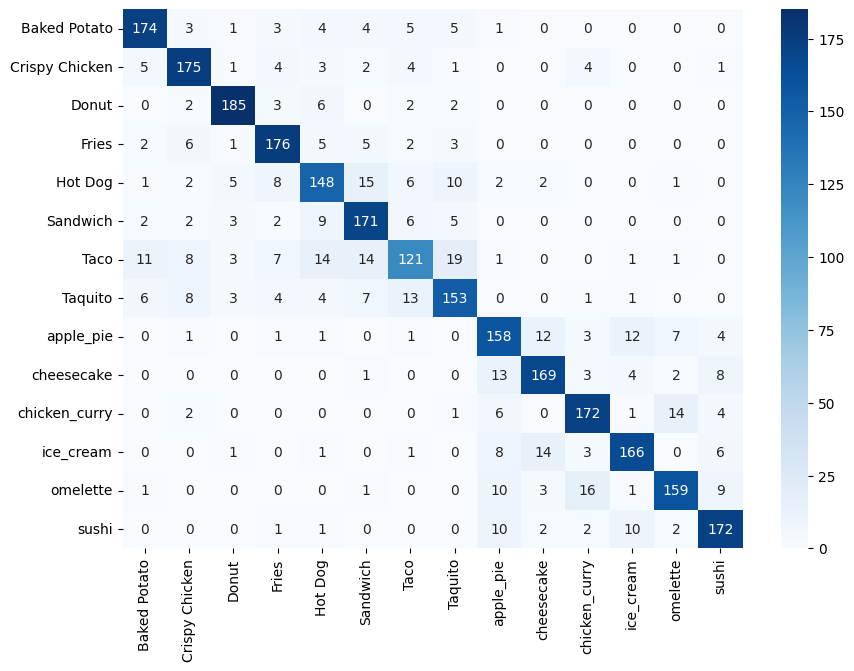

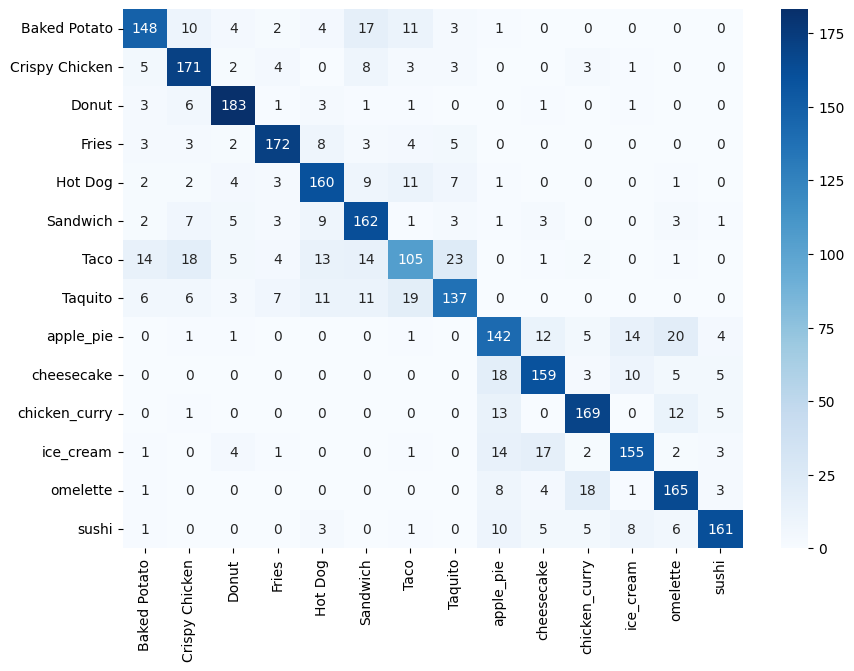

In [ ]:
def plot_confusion_matrix(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for data in loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=trainset.classes, yticklabels=trainset.classes, cmap='Blues')
    plt.show()

# Confusion Matrix per VGG

plot_confusion_matrix(vgg, testloader, device)

# Confusion Matrix per efficientnet

plot_confusion_matrix(efficientnet, testloader, device)

### ***Conclusione del progetto***

Il progetto mi ha permesso di implementare una pipeline completa di classificazione immagini tramite transfer learning. Grazie ai metodi di augmentation e normalizzazione, ho potuto comprendere come la rete VGG16 possa raggiungere ottimi risultati in termini di accuratezza e metriche di classificazione (precision, recall, f1-score).

Sebbene sia stato incluso il codice per il modello EfficientNetV2, non è stato possibile eseguirne l’addestramento per motivi legati alle limitazioni delle risorse cloud disponibili. Tuttavia, il notebook è pronto per accogliere future sperimentazioni non appena saranno disponibili maggiori risorse computazionali.

L’esperienza ha consolidato la mia conoscenza dei principali modelli di lavoro in ambito deep learning, dell’uso delle reti pre-addestrate e delle metodologie di valutazione dei modelli su dataset reali.